<a href="https://colab.research.google.com/github/Eddythemachine/intro_to_cnn/blob/main/Intro_to_Computer_Vision_with_Tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Intro to Computer Vision with Tensorflow


# Lib Import

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import pathlib
import matplotlib.image as mpimg
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import Data

In [2]:
# Download dataset
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip

# Unzip dataset
zip_ref = zipfile.ZipFile("pizza_steak.zip", "r")
zip_ref.extractall()
zip_ref.close()

--2026-03-16 19:45:41--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 64.233.170.207, 142.251.10.207, 142.251.12.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|64.233.170.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M  23.4MB/s    in 6.1s    

2026-03-16 19:45:47 (17.3 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



# EDA

In [3]:
!ls pizza_steak

test  train


In [4]:
!ls pizza_steak/train

pizza  steak


In [5]:
!ls pizza_steak/train/steak

1000205.jpg  1647351.jpg  2238681.jpg  2824680.jpg  3375959.jpg  417368.jpg
100135.jpg   1650002.jpg  2238802.jpg  2825100.jpg  3381560.jpg  4176.jpg
101312.jpg   165639.jpg   2254705.jpg  2826987.jpg  3382936.jpg  42125.jpg
1021458.jpg  1658186.jpg  225990.jpg   2832499.jpg  3386119.jpg  421476.jpg
1032846.jpg  1658443.jpg  2260231.jpg  2832960.jpg  3388717.jpg  421561.jpg
10380.jpg    165964.jpg   2268692.jpg  285045.jpg   3389138.jpg  438871.jpg
1049459.jpg  167069.jpg   2271133.jpg  285147.jpg   3393547.jpg  43924.jpg
1053665.jpg  1675632.jpg  227576.jpg   2855315.jpg  3393688.jpg  440188.jpg
1068516.jpg  1678108.jpg  2283057.jpg  2856066.jpg  3396589.jpg  442757.jpg
1068975.jpg  168006.jpg   2286639.jpg  2859933.jpg  339891.jpg	 443210.jpg
1081258.jpg  1682496.jpg  2287136.jpg  286219.jpg   3417789.jpg  444064.jpg
1090122.jpg  1684438.jpg  2291292.jpg  2862562.jpg  3425047.jpg  444709.jpg
1093966.jpg  168775.jpg   229323.jpg   2865730.jpg  3434983.jpg  447557.jpg
1098844.jpg  1697

In [6]:
import os
for dirpath, dirnames, filenames in os.walk("pizza_steak"):
    print(f"There are {len(dirnames)}, directories and {len(filenames)} images in {dirpath}")

There are 2, directories and 0 images in pizza_steak
There are 2, directories and 0 images in pizza_steak/test
There are 0, directories and 250 images in pizza_steak/test/pizza
There are 0, directories and 250 images in pizza_steak/test/steak
There are 2, directories and 0 images in pizza_steak/train
There are 0, directories and 750 images in pizza_steak/train/pizza
There are 0, directories and 750 images in pizza_steak/train/steak


In [7]:
!ls -la pizza_steak

total 16
drwxr-xr-x 4 root root 4096 Mar 16 19:45 .
drwxr-xr-x 1 root root 4096 Mar 16 19:45 ..
drwxr-xr-x 4 root root 4096 Mar 16 19:45 test
drwxr-xr-x 4 root root 4096 Mar 16 19:45 train


In [8]:
num_steak_images_train = len(os.listdir("pizza_steak/train/steak"))
num_steak_images_train

750

In [9]:
data_dir = pathlib.Path("pizza_steak/train")
class_names = np.array(sorted([item.name for item in data_dir.glob("*")])) # Create a list of classnames from the subdirectories
print(class_names)

['pizza' 'steak']


In [10]:
def view_random_image(target_dir, target_class):

    target_folder = target_dir+target_class

    random_image = random.sample(os.listdir(target_folder), 1)
    img = mpimg.imread(target_folder + "/" + random_image[0] )
    plt.imshow(img)
    plt.title(target_class)
    plt.axis("off")
    print(f"Image shape {img.shape}")

    return img

Image shape (384, 512, 3)


array([[[ 99, 127,  79],
        [ 98, 135,  81],
        [ 93, 146,  78],
        ...,
        [100,  81,  77],
        [ 95,  85,  58],
        [ 91,  86,  48]],

       [[118, 130,  92],
        [115, 134,  89],
        [105, 141,  80],
        ...,
        [ 78,  91,  45],
        [ 86,  88,  48],
        [ 90,  88,  50]],

       [[116, 133,  99],
        [113, 135,  96],
        [104, 139,  83],
        ...,
        [ 64,  91,  38],
        [ 72,  87,  58],
        [ 80,  89,  72]],

       ...,

       [[ 98, 138,  86],
        [ 93, 135,  85],
        [ 87, 131,  80],
        ...,
        [ 82, 109,  76],
        [ 81, 107,  70],
        [ 75, 101,  64]],

       [[102, 138,  68],
        [ 99, 136,  67],
        [ 92, 132,  69],
        ...,
        [ 73, 109,  81],
        [ 69, 109,  85],
        [ 67, 106,  85]],

       [[107, 137,  49],
        [104, 136,  51],
        [ 98, 135,  55],
        ...,
        [ 70, 109, 108],
        [ 69, 109, 121],
        [ 73, 114, 132]]], dtype=uint8)
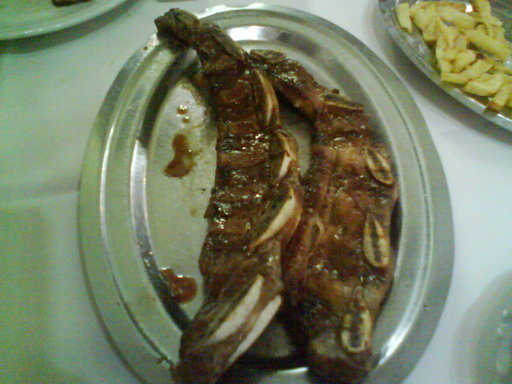

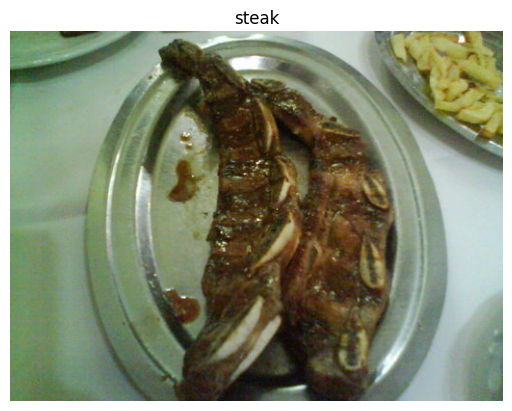

In [11]:
view_random_image(target_dir="pizza_steak/train/",
                  target_class="steak")

In [12]:
# Set seed
tf.random.set_seed(42)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training generator (with augmentation + validation split)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,     # 20% of train data becomes validation
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Test generator (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

train_dir = "/content/pizza_steak/train"
test_dir = "/content/pizza_steak/test"

# Training data (80%)
train_data = train_datagen.flow_from_directory(
    directory=train_dir,
    batch_size=32,
    target_size=(224,224),
    color_mode="grayscale",
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

# Validation data (20% from train folder)
valid_data = train_datagen.flow_from_directory(
    directory=train_dir,
    batch_size=32,
    target_size=(224,224),
    color_mode="grayscale",
    class_mode="binary",
    subset="validation",
    shuffle=True,
    seed=42
)

# Test data
test_data = test_datagen.flow_from_directory(
    directory=test_dir,
    batch_size=32,
    target_size=(224,224),
    color_mode="grayscale",
    class_mode="binary",
    shuffle=False,
    seed=42
)

Found 1200 images belonging to 2 classes.
Found 300 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


# MODEL 1

In [ ]:
# Set seed
tf.random.set_seed(42)

model_1 = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=(3,3),
        activation="relu",
        input_shape=(224,224,1),
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Conv2D(
        filters=10,
        kernel_size=(3,3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")   # binary classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

In [13]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",        # watch validation loss
    patience=5,                # stop after 5 epochs without improvement
    restore_best_weights=True  # load best model weights
)

In [ ]:
history = model_1.fit(
    train_data,
    epochs=50,
    validation_data=valid_data,
    callbacks=[early_stop]
)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 308ms/step - accuracy: 0.5367 - loss: 0.6917 - val_accuracy: 0.6133 - val_loss: 0.6883
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 246ms/step - accuracy: 0.6383 - loss: 0.6677 - val_accuracy: 0.5267 - val_loss: 0.6875
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 243ms/step - accuracy: 0.6633 - loss: 0.6154 - val_accuracy: 0.6567 - val_loss: 0.6182
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 224ms/step - accuracy: 0.6983 - loss: 0.5715 - val_accuracy: 0.6533 - val_loss: 0.6048
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 223ms/step - accuracy: 0.7408 - loss: 0.5448 - val_accuracy: 0.6800 - val_loss: 0.5948
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.7458 - loss: 0.5306 - val_accuracy: 0.6367 - val_loss: 0.6079
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 237ms/step - accuracy: 0.7500 - loss: 0.5211 - val_accuracy: 0.7300 - val_loss: 0.5631
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 212ms/step - accuracy: 0.7475 - loss: 0.5230 - val_accuracy: 0

In [ ]:
model_1.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8160 - loss: 0.4230


[0.42303213477134705, 0.8159999847412109]

# Model 2

In [ ]:
# Set seed
tf.random.set_seed(42)

# Model 2: deeper CNN
model_2 = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same",
                           input_shape=(224,224,1)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    tf.keras.layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.Conv2D(256, (3,3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(2),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_2.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)

In [14]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

# Add [reduce_lr] to your callbacks list in model.fit()
def train_model(model, train_data, valid_data, epochs=50):

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        train_data,
        epochs=epochs,
        validation_data=valid_data,
        callbacks=[early_stop, reduce_lr]
    )

    return history, model

In [ ]:
history_2, model = train_model(model_2, train_data, valid_data)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 457ms/step - accuracy: 0.5100 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 339ms/step - accuracy: 0.5067 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 329ms/step - accuracy: 0.5058 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 321ms/step - accuracy: 0.5008 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 316ms/step - accuracy: 0.5217 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 310ms/step - accuracy: 0.5225 - loss: 0.6929 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 13s 331ms/step - accuracy: 0.4958 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6929
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 323ms/step - accuracy: 0.5258 - loss: 0.6929 - val_accu

In [ ]:
model.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step - accuracy: 0.6740 - loss: 0.6652


[0.665227472782135, 0.6740000247955322]

In [17]:
# Set random seed for reproducibility
tf.random.set_seed(42)

model_3 = tf.keras.models.Sequential([
    # Input Layer
    tf.keras.layers.Input(shape=(224, 224, 1)),

    # Block 1: Initial Feature Extraction
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Block 2: Capturing Patterns
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Block 3: Complex Texture Extraction
    tf.keras.layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Block 4: Deep Features
    tf.keras.layers.Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    tf.keras.layers.GlobalAveragePooling2D(), # Reduces 256 feature maps to 256 single values

    # Classifier Head
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
], name="Deep_Feature_Model_V3")

In [19]:
model_3.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)

In [20]:
history_3, model_3 = train_model(model_3, train_data, valid_data)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 497ms/step - accuracy: 0.6217 - loss: 0.6538 - val_accuracy: 0.5033 - val_loss: 0.7182 - learning_rate: 0.0100
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step - accuracy: 0.7500 - loss: 0.5629 - val_accuracy: 0.4833 - val_loss: 0.7217 - learning_rate: 0.0100
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step - accuracy: 0.7692 - loss: 0.5266 - val_accuracy: 0.5367 - val_loss: 0.7007 - learning_rate: 0.0100
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 282ms/step - accuracy: 0.7800 - loss: 0.4872 - val_accuracy: 0.5867 - val_loss: 0.6672 - learning_rate: 0.0100
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 279ms/step - accuracy: 0.7817 - loss: 0.4795 - val_accuracy: 0.6300 - val_loss: 0.6591 - learning_rate: 0.0100
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 279ms/step - accuracy: 0.8025 - loss: 0.4586 - val_accuracy: 0.6267 - val_loss: 0.6295 - learning_rate: 0.0100
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 281ms/step - accuracy: 0.7867 - loss: 0.

In [21]:
model_3.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - accuracy: 0.8480 - loss: 0.3419


[0.3418681025505066, 0.8479999899864197]

In [22]:
y_pred = model_3.predict(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 161ms/step


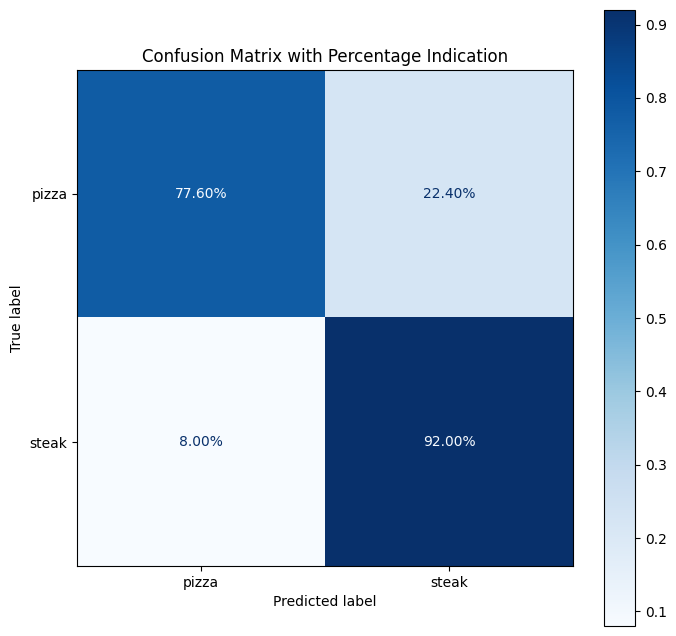

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels from test_data
y_true = test_data.classes

# Convert predicted probabilities to binary classes (0 or 1)
y_pred_classes = tf.round(y_pred)

# Create and display the confusion matrix with percentages
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_classes,
    display_labels=class_names,
    cmap=plt.cm.Blues,
    ax=ax,
    normalize='true',
    values_format='.2%'
)
plt.title('Confusion Matrix with Percentage Indication')
plt.show()